# LDA Y LSD

In [1]:
import pandas as pd
import re
import nltk 
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import gensim
import gensim.corpora as corpora
from gensim.models import LsiModel
from gensim.models.coherencemodel import CoherenceModel
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\pc\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
data = pd.read_csv("news_articles_espanol.csv", sep=";", engine="python")

In [3]:
data.head(5)

,id,title,content
0,1,Debate político sobre reformas laborales,Empresas tecnológicas están invirtiendo grande...
1,2,El gobierno anuncia nuevas medidas económicas,Las autoridades locales informan de un increme...
2,3,Innovación en transporte sostenible,Los proyectos de energía solar y eólica contin...
3,4,Investigadores descubren nueva terapia contra ...,Universidades y centros de investigación están...
4,5,El gobierno anuncia nuevas medidas económicas,Los partidos políticos discuten nuevas propues...


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       100 non-null    int64 
 1   title    100 non-null    object
 2   content  100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


### Limpiando los datos

In [5]:
articles = data['content'].str.lower().apply(lambda x: re.sub(r"([^\w\s])", "", x))

In [6]:
en_stopwords = stopwords.words('spanish')
articles = articles.apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [7]:
articles = articles.apply(lambda x: word_tokenize(x))

In [8]:
ps = PorterStemmer()
articles = articles.apply(lambda tokens: [ps.stem(token) for token in tokens])

In [9]:
articles

0     [empresa, tecnológica, invirtiendo, grand, rec...
1     [autoridad, local, informan, incremento, notab...
2     [proyecto, energía, solar, eólica, continúan, ...
3     [universidad, centro, investigación, adoptando...
4     [partido, político, discuten, nueva, propuesta...
                            ...                        
95    [experto, señalan, nueva, política, podrían, i...
96    [ingeniero, trabajan, solucion, reduzcan, emis...
97    [proyecto, energía, solar, eólica, continúan, ...
98    [autoridad, local, informan, incremento, notab...
99    [empresa, tecnológica, invirtiendo, grand, rec...
Name: content, Length: 100, dtype: object

## Vectorizatión

In [10]:
dictionary = corpora.Dictionary(articles)
print(dictionary)

Dictionary<86 unique tokens: ['artifici', 'desarrollo', 'empresa', 'grand', 'inteligencia']...>


In [11]:
doc_term = [dictionary.doc2bow(text) for text in articles]

In [12]:
print(doc_term)

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)], [(9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1)], [(17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1)], [(26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1)], [(30, 1), (32, 1), (35, 1), (36, 1), (37, 1), (38, 1), (39, 1), (40, 1)], [(41, 1), (42, 1), (43, 1), (44, 1), (45, 1), (46, 1), (47, 1), (48, 1), (49, 1), (50, 1), (51, 1)], [(26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 1)], [(52, 1), (53, 1), (54, 1), (55, 1), (56, 1), (57, 1), (58, 1), (59, 1), (60, 1)], [(9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1)], [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1)], [(61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 1)], [(17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1)], [(41, 1), (42, 1), (43, 1), (44, 1), (45,

## LDA

In [13]:
num_topics = 2 # especificar el número de temas

In [14]:
lda_model = gensim.models.LdaModel(corpus=doc_term,
                                   id2word=dictionary,
                                   num_topics=num_topics)  # crear modelo LDA

In [15]:
lda_model.print_topics(num_topics=num_topics, num_words=5)

[(0,
  '0.060*"nueva" + 0.025*"mejorar" + 0.021*"posibilidad" + 0.021*"abr" + 0.021*"revista"'),
 (1,
  '0.030*"notabl" + 0.029*"internacional" + 0.029*"informan" + 0.029*"llegada" + 0.029*"local"')]

## LSA

In [16]:
num_topics = 2

In [17]:
# crear LSD model
lsamodel = LsiModel(doc_term, num_topics=num_topics, id2word = dictionary) 
print(lsamodel.print_topics(num_topics=num_topics, num_words=5))

[(0, '-0.333*"recurso" + -0.333*"tecnológica" + -0.333*"desarrollo" + -0.333*"grand" + -0.333*"empresa"'), (1, '-0.302*"década" + -0.302*"advierten" + -0.302*"persona" + -0.302*"nivel" + -0.302*"afectar"')]


### Determinar el número de temas

In [18]:
coherence_values = []
model_list = []

min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = LsiModel(doc_term, num_topics=num_topics_i, id2word = dictionary, random_seed=0)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=articles, dictionary=dictionary, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

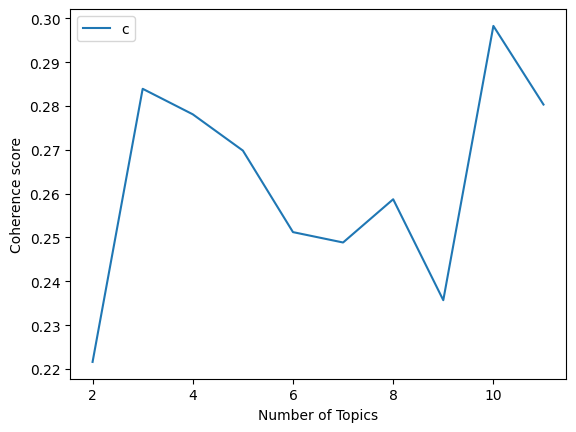

In [19]:
plt.plot(range(min_topics, max_topics+1), coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence score")
plt.legend(("coherence_values"), loc='best')
plt.show()

In [20]:
final_n_topics = 3
lsamodel_f = LsiModel(doc_term, num_topics=final_n_topics, id2word = dictionary) 
print(lsamodel_f.print_topics(num_topics=final_n_topics, num_words=5))

[(0, '-0.333*"grand" + -0.333*"inteligencia" + -0.333*"tecnológica" + -0.333*"artifici" + -0.333*"invirtiendo"'), (1, '0.302*"millon" + 0.302*"aumento" + 0.302*"científico" + 0.302*"afectar" + 0.302*"mar"'), (2, '0.354*"local" + 0.354*"llegada" + 0.354*"informan" + 0.354*"visitant" + 0.354*"notabl"')]


# Construyendo un clasificador personalizado

In [21]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [22]:
data = pd.DataFrame([
("me encanta pasar tiempo con mi familia los fines de semana", "positive"),
("hoy tuve un día maravilloso lleno de buenas noticias", "positive"),
("estoy muy agradecido por todas las oportunidades que tengo", "positive"),
("mi equipo ganó el partido y estoy muy feliz", "positive"),
("disfruté mucho la comida en ese restaurante", "positive"),
("terminé mi proyecto con éxito y me siento orgulloso", "positive"),
("escuchar música siempre mejora mi estado de ánimo", "positive"),
("recibí buenas noticias sobre mi trabajo hoy", "positive"),
("mis amigos me organizaron una sorpresa muy bonita", "positive"),
("el viaje fue increíble y aprendí muchas cosas nuevas", "positive"),

("hoy fue un día muy estresante en el trabajo", "negative"),
("me siento cansado y frustrado con todos estos problemas", "negative"),
("el tráfico esta mañana fue terrible", "negative"),
("estoy triste porque perdí mi teléfono", "negative"),
("la reunión fue muy aburrida y larga", "negative"),
("no me gustó la comida de ese restaurante", "negative"),
("mi computadora dejó de funcionar y perdí mi trabajo", "negative"),
("estoy decepcionado con los resultados del examen", "negative"),
("tuve una discusión con un amigo y me siento mal", "negative"),
("el servicio en la tienda fue muy malo", "negative")

], columns=['text','sentiment'])

In [23]:
data = data.sample(frac=1).reset_index(drop=True)

In [24]:
X = data['text']
y = data['sentiment']

In [25]:
countvec = CountVectorizer()
countvec_fit = countvec.fit_transform(X)
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns = countvec.get_feature_names_out())

In [26]:
bag_of_words

,aburrida,agradecido,amigo,amigos,aprendí,bonita,buenas,cansado,comida,computadora,...,todos,trabajo,triste,tráfico,tuve,un,una,viaje,ánimo,éxito
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,1,1,1,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
X_train, X_test, y_train, y_test = train_test_split(bag_of_words, y, test_size=0.3, random_state = 7)

## Regresión logística

In [28]:
lr = LogisticRegression(random_state=1).fit(X_train, y_train)

In [29]:
y_pred_lr = lr.predict(X_test)

In [30]:
accuracy_score(y_pred_lr, y_test)

0.5

In [31]:
y_pred_lr

array(['negative', 'positive', 'positive', 'negative', 'negative',
       'negative'], dtype=object)

In [32]:
y_test

1     negative
17    positive
2     negative
5     positive
11    negative
0     positive
Name: sentiment, dtype: object

In [33]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

    negative       0.50      0.67      0.57         3
    positive       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



## Bayes ingenuo

In [34]:
from sklearn.naive_bayes import MultinomialNB

In [35]:
nb = MultinomialNB().fit(X_train, y_train)

In [36]:
y_pred_nb = nb.predict(X_test)

In [37]:
accuracy_score(y_pred_nb, y_test)

0.3333333333333333

In [38]:
print(classification_report(y_test, y_pred_nb, zero_division=0))

              precision    recall  f1-score   support

    negative       0.40      0.67      0.50         3
    positive       0.00      0.00      0.00         3

    accuracy                           0.33         6
   macro avg       0.20      0.33      0.25         6
weighted avg       0.20      0.33      0.25         6



## Máquina de vectores de soporte lineal

In [39]:
from sklearn.linear_model import LogisticRegression, SGDClassifier

In [40]:
svm = SGDClassifier().fit(X_train, y_train)

In [41]:
y_pred_svm = svm.predict(X_test)

In [42]:
accuracy_score(y_pred_svm, y_test)

0.5

In [43]:
print(classification_report(y_test, y_pred_svm, zero_division=0))

              precision    recall  f1-score   support

    negative       0.50      0.33      0.40         3
    positive       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6

